# Superstore Analysis

### This is the first official attempt at analysis on python

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import FacetGrid

### Initial loadings, data exploration, cleaning, wrangling

In [15]:
superstore = pd.read_excel(
    'Sample - Superstore Subset (Excel).xlsx',
    index_col='Row ID'
)
print(superstore.head(5))
print(superstore.info)
print(superstore.isna().sum())
print(superstore.dtypes)


       Order Priority  Discount  Unit Price  Shipping Cost  Customer ID  \
Row ID                                                                    
18606   Not Specified      0.01        2.88           0.50            2   
20847            High      0.01        2.84           0.93            3   
23086   Not Specified      0.03        6.68           6.15            3   
23087   Not Specified      0.01        5.68           3.60            3   
23088   Not Specified      0.00      205.99           2.50            3   

          Customer Name    Ship Mode Customer Segment Product Category  \
Row ID                                                                   
18606   Janice Fletcher  Regular Air        Corporate  Office Supplies   
20847     Bonnie Potter  Express Air        Corporate  Office Supplies   
23086     Bonnie Potter  Express Air        Corporate  Office Supplies   
23087     Bonnie Potter  Regular Air        Corporate  Office Supplies   
23088     Bonnie Potter  Expre

In [17]:
superstore[superstore.isna().any(axis=1)]


,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,Product Sub-Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
Row ID,,,,,,,,,,,,,,,,,,,,,
23945,High,0.04,276.20,24.49,50,Dawn Bailey,Regular Air,Corporate,Furniture,Chairs & Chairmats,...,Central,Illinois,Tinley Park,60477,2011-03-29,2011-04-01,1585.0887,8,2297.23,87710
25360,Critical,0.01,42.76,6.22,122,Miriam Proctor,Regular Air,Home Office,Office Supplies,Storage & Organization,...,West,California,Visalia,93277,2012-04-11,2012-04-12,217.9365,7,315.85,90670
23701,High,0.10,42.76,6.22,167,Carla Braun,Regular Air,Consumer,Office Supplies,Storage & Organization,...,South,Tennessee,Maryville,37804,2011-06-23,2011-06-24,-66.5560,7,287.97,89427
21923,High,0.08,26.64,5.30,256,Irene Li,Regular Air,Home Office,Furniture,Chairs & Chairmats,...,East,Pennsylvania,Hanover,17331,2011-10-07,2011-10-08,116.9964,16,410.25,86271
18261,Critical,0.06,276.20,24.49,335,Curtis O'Connell,Regular Air,Corporate,Furniture,Chairs & Chairmats,...,West,Oregon,Medford,97504,2010-05-04,2010-05-05,2639.4708,14,3825.32,87277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6625,High,0.06,128.24,12.65,3251,Peter Brooks,Regular Air,Small Business,Furniture,Chairs & Chairmats,...,East,New York,New York City,10112,2012-09-11,2012-09-13,1844.9600,92,12002.16,47109
18728,Not Specified,0.01,349.45,60.00,3257,Sharon Marcus,Delivery Truck,Consumer,Furniture,Tables,...,West,Washington,Longview,98632,2010-05-26,2010-05-27,3739.3929,15,5419.41,88825
23182,Critical,0.09,276.20,24.49,3380,Eva Decker,Regular Air,Home Office,Furniture,Chairs & Chairmats,...,South,Georgia,La Grange,30240,2010-10-20,2010-10-21,3193.2840,11,2941.42,88838


## Order Priority EDAs

In [21]:
print(superstore["Order Priority"].unique())

['Not Specified' 'High' 'Medium' 'Low' 'Critical' 'Critical ']


In [23]:
superstore["Order Priority"] = superstore["Order Priority"].str.strip().str.title()
print(superstore['Order Priority'].unique())

['Not Specified' 'High' 'Medium' 'Low' 'Critical']


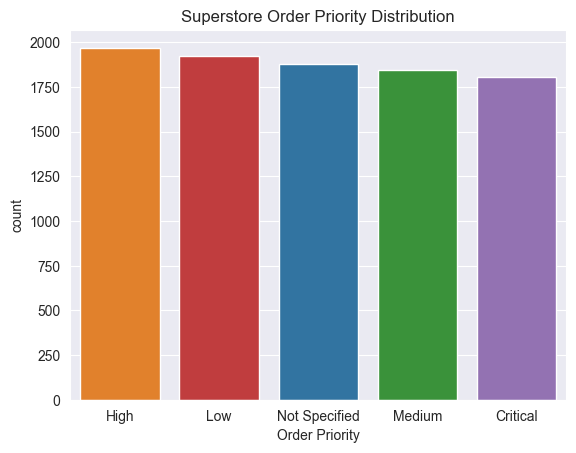

In [30]:
fig, ax = plt.subplots()

sns.countplot(x='Order Priority', data=superstore, ax=ax, order=superstore["Order Priority"].value_counts().index, hue='Order Priority')

ax.set_title("Superstore Order Priority Distribution")

plt.show()

### Who tends to choose between the Order Priorities?

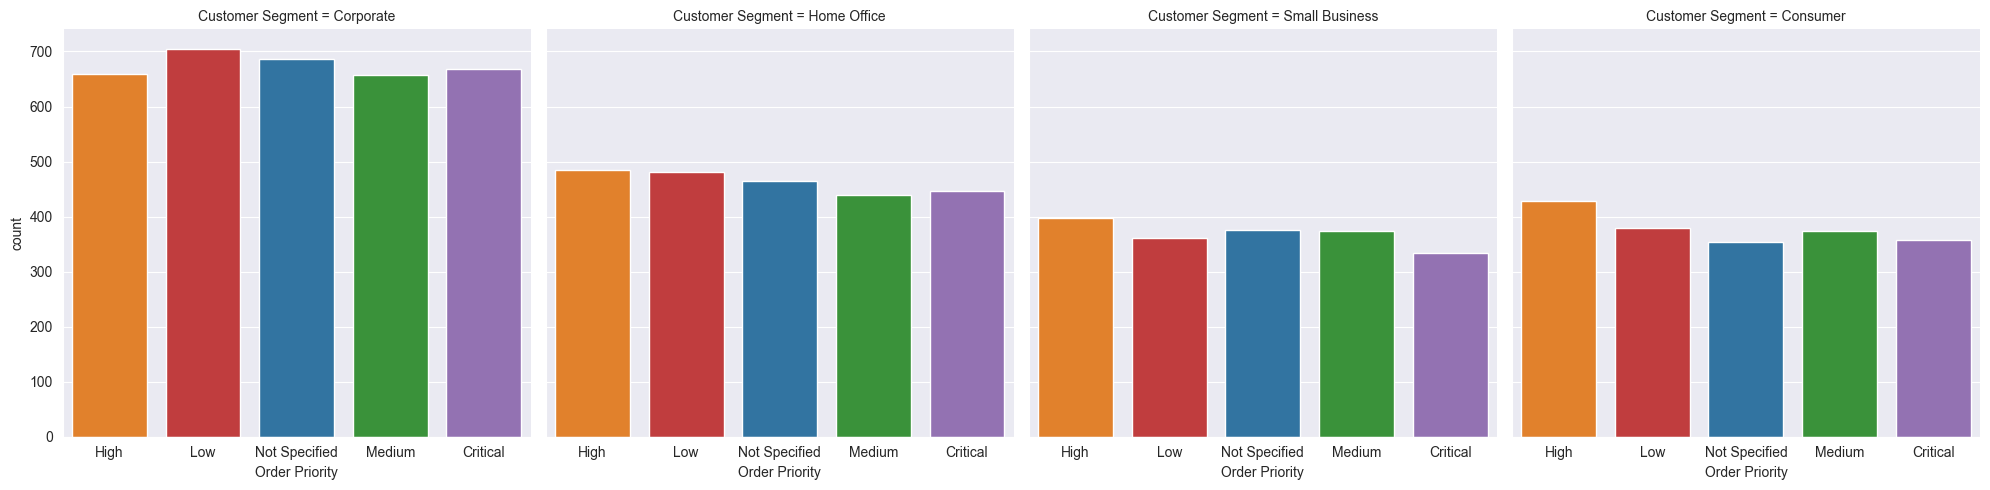

In [54]:
order = superstore['Order Priority'].value_counts().index

sns.catplot(
    data=superstore,
    x='Order Priority',
    col='Customer Segment',
    kind='count',
    order=order,
    hue='Order Priority'
)

ax.set_title("Superstore Order Priority Distribution by Segment")

plt.tight_layout()
plt.show()

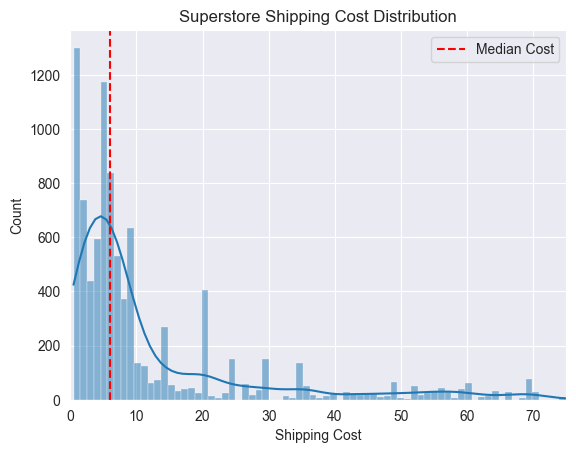

In [49]:
fig, ax = plt.subplots()

sns.histplot(x='Shipping Cost', data=superstore, ax=ax, kde=True)
ax.set_title("Superstore Shipping Cost Distribution")
ax.axvline(superstore['Shipping Cost'].median(), color='r', linestyle='--', label='Median Cost')
ax.set_xlim(0, 75)
ax.legend()

plt.show()

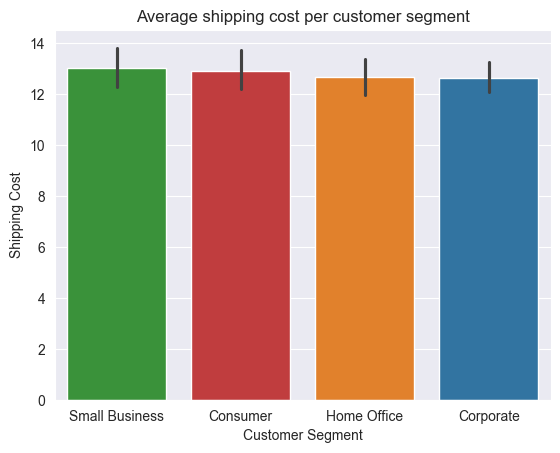

In [57]:
fig, ax = plt.subplots()

order = superstore.groupby('Customer Segment')['Shipping Cost'].mean().sort_values(ascending=False).index

sns.barplot(x='Customer Segment', y='Shipping Cost', data=superstore, ax=ax, order=order, hue='Customer Segment')

ax.set_title('Average shipping cost per customer segment')

plt.show()

## Plots  suggested by ChatGPT

In [58]:
# Helpful engineered fields
superstore["Profit Margin"] = superstore["Profit"] / superstore["Sales"]
superstore["Ship Days"] = (superstore["Ship Date"] - superstore["Order Date"]).dt.days
superstore["Order Month"] = superstore["Order Date"].dt.to_period("M").dt.to_timestamp()

### Monthly Sales vs Monthly profut

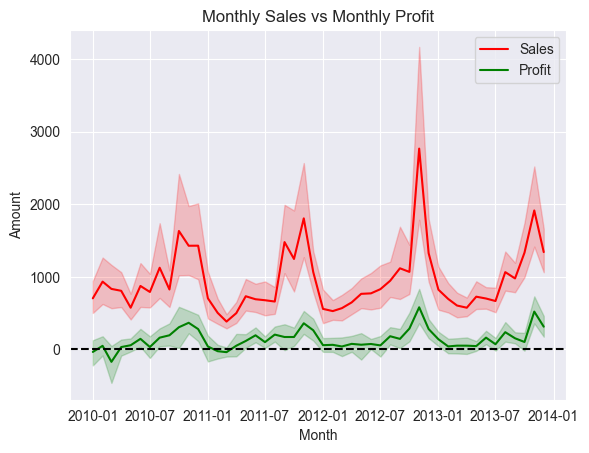

In [60]:
fig, ax = plt.subplots()

sns.lineplot(x='Order Month', y='Sales', data=superstore, ax=ax, color='red', label='Sales')
sns.lineplot(x='Order Month', y='Profit', data=superstore, ax=ax, color='green', label='Profit')
ax.axhline(0, color='k', linestyle='--')
ax.set_xlabel('Month')
ax.set_ylabel('Amount')
ax.set_title('Monthly Sales vs Monthly Profit')
ax.legend()
plt.show()

### Profit Distribution

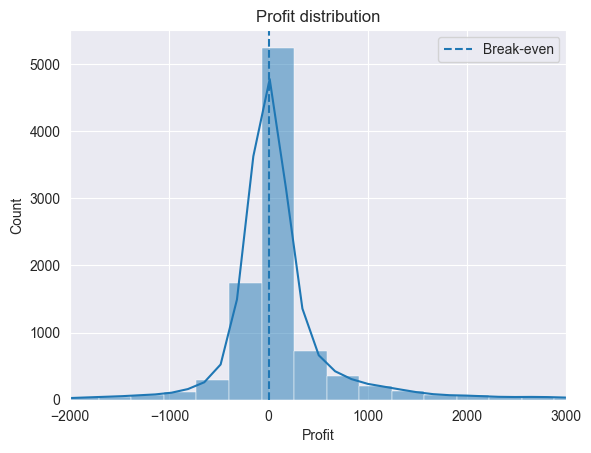

In [68]:
fig, ax = plt.subplots()

sns.histplot(superstore['Profit'], ax=ax, kde=True, bins=100)
ax.axvline(0, linestyle='--', label='Break-even')
ax.set_xlim(-2000, 3000)
ax.set_title('Profit distribution')
ax.legend()
plt.show()

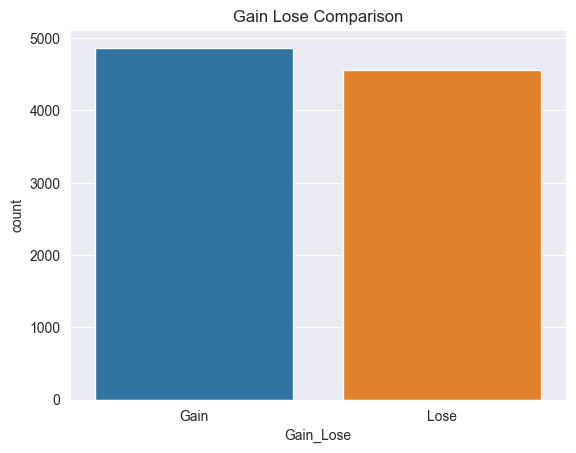

In [69]:
superstore['Gain_Lose'] = np.where(superstore['Profit'] > 0, 'Gain', 'Lose')

fig, ax = plt.subplots()

sns.countplot(x='Gain_Lose', data=superstore, ax=ax, hue='Gain_Lose')
ax.set_title("Gain Lose Comparison")
plt.show()

### Sales vs Profit Scatter (colored by product category)

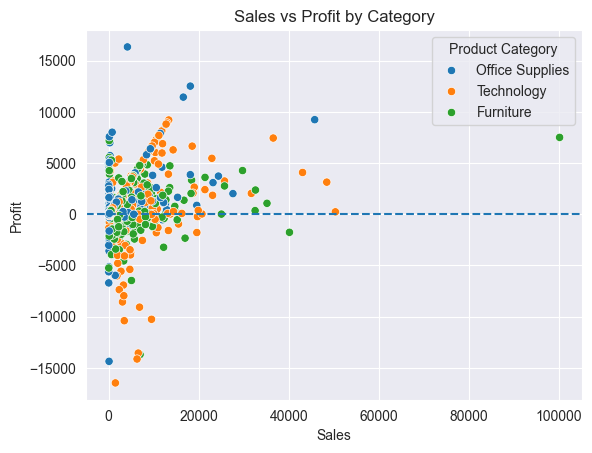

In [71]:
fig, ax = plt.subplots()

sns.scatterplot(x='Sales', y='Profit', hue='Product Category', data=superstore, ax=ax)
ax.set_xlabel('Sales')
ax.set_ylabel('Profit')
ax.axhline(0, linestyle='--', label='Break-even')
ax.set_title("Sales vs Profit by Category")
plt.show()

### Discount vs Profit (with trend line)

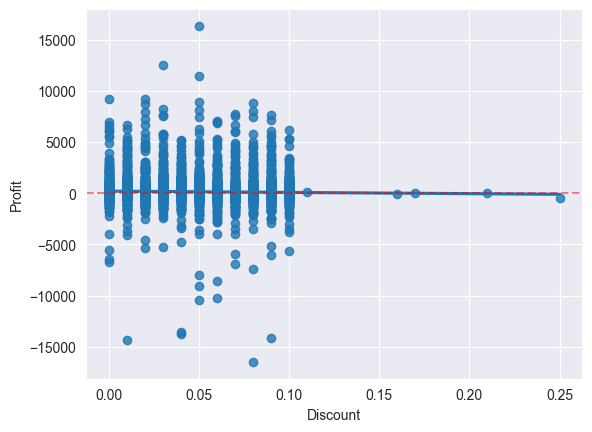

In [73]:
fig, ax = plt.subplots()

sns.regplot(x='Discount', y='Profit', data=superstore, ax=ax)
ax.set_xlabel('Discount')
ax.set_ylabel('Profit')
ax.axhline(0, linestyle='--', alpha=0.5, color='r')
plt.show()

### Profit Margin by Customer Segment (boxplot)

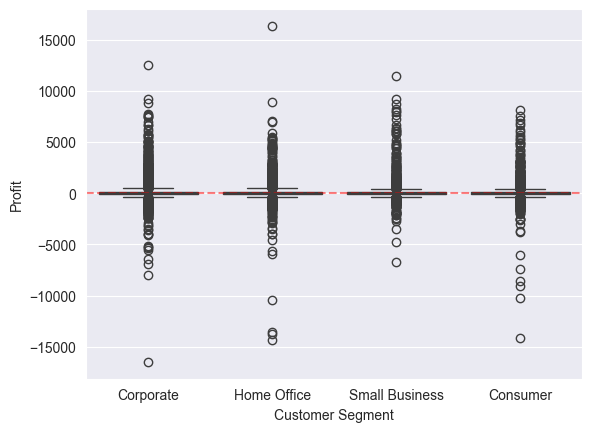

In [75]:
fig , ax = plt.subplots()

sns.boxplot(x='Customer Segment', y='Profit', data=superstore, ax=ax, hue='Customer Segment')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Profit')
ax.axhline(0, linestyle='--', alpha=0.5, color='r')
plt.show()

### Profit Margin by Customer Segment (boxplot) with outliers removed

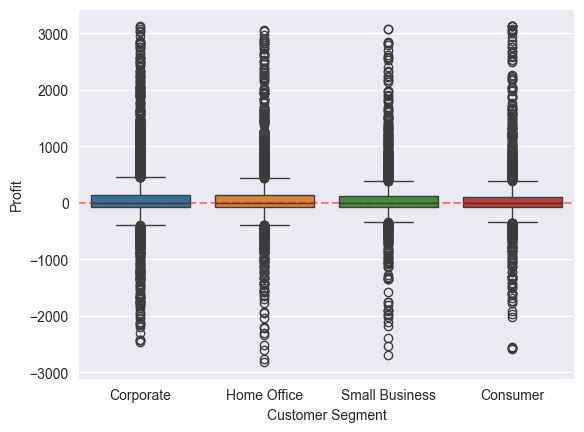

In [79]:
superstore_copy = superstore.copy()
superstore_copy['Profit_zscore'] = (superstore_copy['Profit'] - superstore_copy['Profit'].mean()) / superstore_copy['Profit'].std()

norm_profit = superstore[superstore_copy['Profit_zscore'].abs() < 3]

fig, ax = plt.subplots()

sns.boxplot(x='Customer Segment' , y='Profit', data=norm_profit, ax=ax, hue='Customer Segment')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Profit')
ax.axhline(0, linestyle='--', alpha=0.5, color='r')

plt.show()

### Top 10 sub-categories by total profit (bar chart)

In [82]:
top_10 = superstore.groupby('Product Sub-Category', as_index=False)['Profit'].sum().sort_values(by='Profit', ascending=False).head(10)

top_10 = top_10.reset_index(drop=True)

print(top_10)

             Product Sub-Category         Profit
0    Telephones and Communication  297950.524866
1  Binders and Binder Accessories  226572.523042
2                 Office Machines  168072.833340
3              Chairs & Chairmats  165348.882760
4                 Copiers and Fax  129156.684030
5                      Appliances  121651.391380
6              Office Furnishings   92209.225867
7            Computer Peripherals   87917.842513
8                       Envelopes   46133.223840
9                           Paper   35361.621738


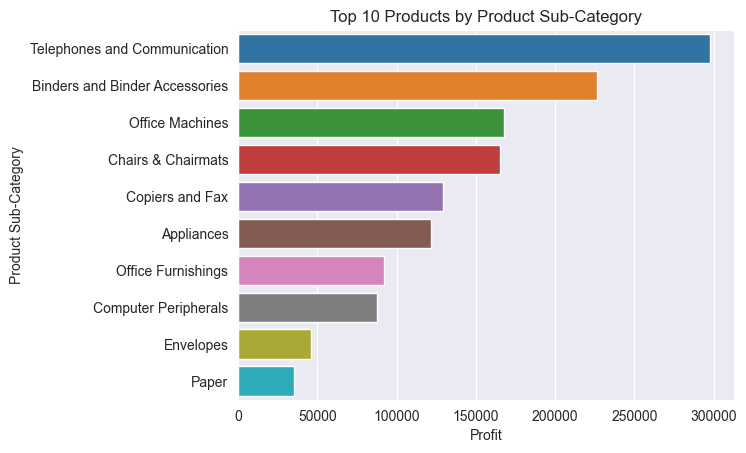

In [85]:
fig , ax = plt.subplots()

sns.barplot(x='Profit', y='Product Sub-Category', data=top_10, ax=ax, hue='Product Sub-Category')
ax.set_xlabel('Profit')
ax.set_ylabel('Product Sub-Category')
ax.set_title('Top 10 Products by Product Sub-Category')
plt.show()

### Bottom 10 sub-categories by total profit (loss leaders)

In [91]:
bottom_10 = superstore.groupby('Product Sub-Category', as_index=False)['Profit'].sum().sort_values(by='Profit', ascending=True).head(7)

bottom_10 = bottom_10.reset_index(drop=True)

print(bottom_10)

            Product Sub-Category        Profit
0                         Tables -72495.061875
1                      Bookcases  -7708.748564
2                   Rubber Bands  -2841.722459
3  Scissors, Rulers and Trimmers  -1936.849120
4            Pens & Art Supplies   1195.902840
5         Storage & Organization   8078.804727
6                         Labels  17775.320505


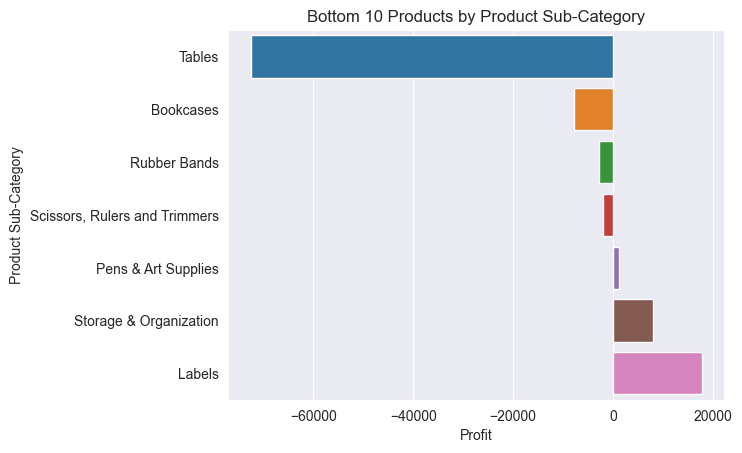

In [90]:
fig, ax = plt.subplots()

sns.barplot(x='Profit', y='Product Sub-Category', data=bottom_10, ax=ax, hue='Product Sub-Category')
ax.set_ylabel('Product Sub-Category')
ax.set_xlabel('Profit')
ax.set_title('Bottom 10 Products by Product Sub-Category')
plt.show()

### Heatmap: Region x Category average Profit Margin

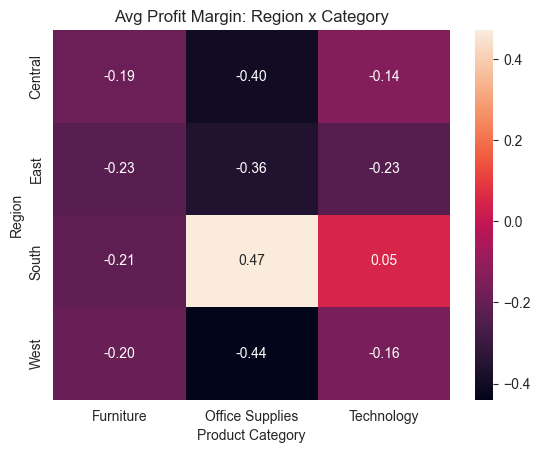

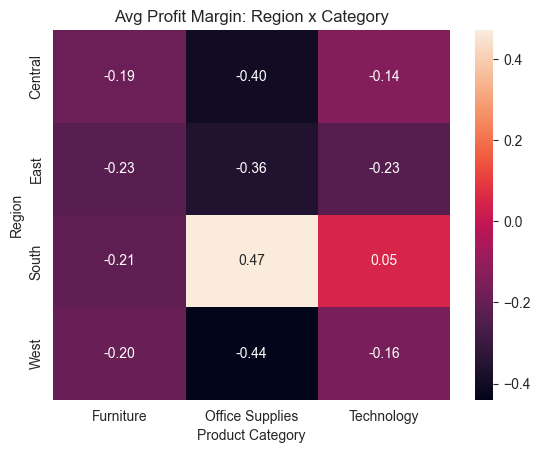

In [93]:
pivot = superstore.pivot_table(
    index="Region",
    columns="Product Category",
    values="Profit Margin",
    aggfunc="mean"
)

fig, ax = plt.subplots()
sns.heatmap(pivot, annot=True, fmt='.2f', ax=ax)
ax.set_title('Avg Profit Margin: Region x Category')
plt.show(0)

### Ship Days by Ship Mode (boxplot)

In [94]:
print(superstore['Ship Mode'].head(10))

Row ID
18606       Regular Air
20847       Express Air
23086       Express Air
23087       Regular Air
23088       Express Air
23597       Express Air
25549    Delivery Truck
20228    Delivery Truck
19483       Regular Air
24782       Regular Air
Name: Ship Mode, dtype: object


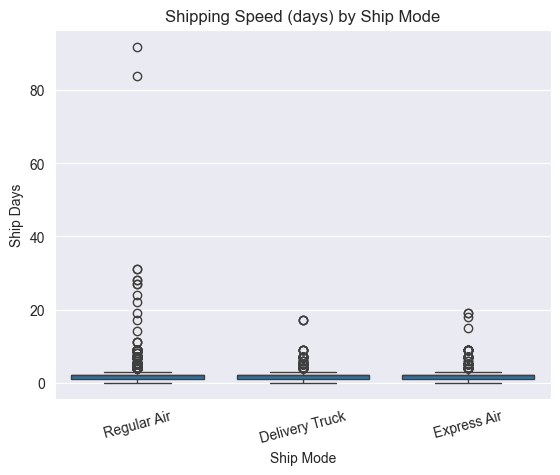

In [95]:
order = superstore['Ship Mode'].value_counts().index

fig, ax = plt.subplots()
sns.boxplot(x='Ship Mode', y='Ship Days', data=superstore, ax=ax, order=order)
ax.set_xlabel('Ship Mode')
ax.set_ylabel('Ship Days')
ax.set_title('Shipping Speed (days) by Ship Mode')
plt.xticks(rotation=15)
plt.show()